In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cardetails.csv")

In [3]:
df.columns = df.columns.str.strip()

In [4]:
print("\n========== BASIC INFO ==========")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:\n", df.describe(include='all'))


========== BASIC INFO ==========
Shape: (8128, 13)

Columns:
 Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

Missing Values:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Data Types:
 name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

Statistical Summary:
                           name         year  selling_price     km_

In [6]:

print("\n========== DATA CLEANING ==========")


========== DATA CLEANING ==========


In [7]:
df['mileage'] = df['mileage'].astype(str).str.replace(' kmpl','').str.replace(' km/kg','')
df['engine'] = df['engine'].astype(str).str.replace(' CC','')
df['max_power'] = df['max_power'].astype(str).str.replace(' bhp','')

In [8]:

df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [9]:
print("\nAfter Cleaning Missing Values:\n", df.isnull().sum())


After Cleaning Missing Values:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
torque           222
seats            221
dtype: int64


In [10]:
print("\n========== CORRELATION MATRIX ==========")
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
print(corr)


========== CORRELATION MATRIX ==========
                   year  selling_price  km_driven   mileage    engine  \
year           1.000000       0.414092  -0.418006  0.329145  0.018848   
selling_price  0.414092       1.000000  -0.225534 -0.126054  0.455734   
km_driven     -0.418006      -0.225534   1.000000 -0.173073  0.205914   
mileage        0.329145      -0.126054  -0.173073  1.000000 -0.575831   
engine         0.018848       0.455734   0.205914 -0.575831  1.000000   
max_power      0.226320       0.748489  -0.038075 -0.374621  0.703975   
seats         -0.009144       0.041358   0.227336 -0.452085  0.610309   

               max_power     seats  
year            0.226320 -0.009144  
selling_price   0.748489  0.041358  
km_driven      -0.038075  0.227336  
mileage        -0.374621 -0.452085  
engine          0.703975  0.610309  
max_power       1.000000  0.191999  
seats           0.191999  1.000000  


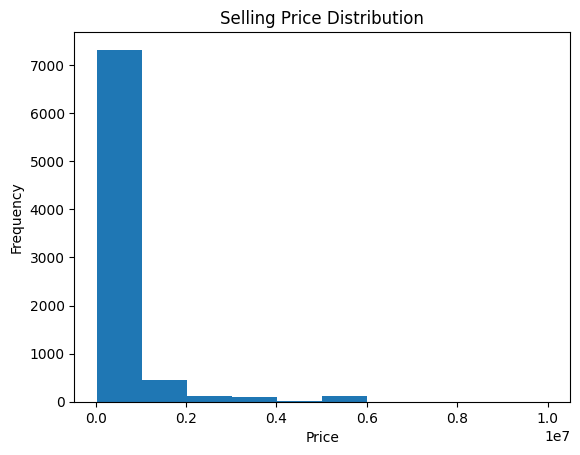

In [11]:
plt.figure()
plt.hist(df['selling_price'])
plt.title("Selling Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

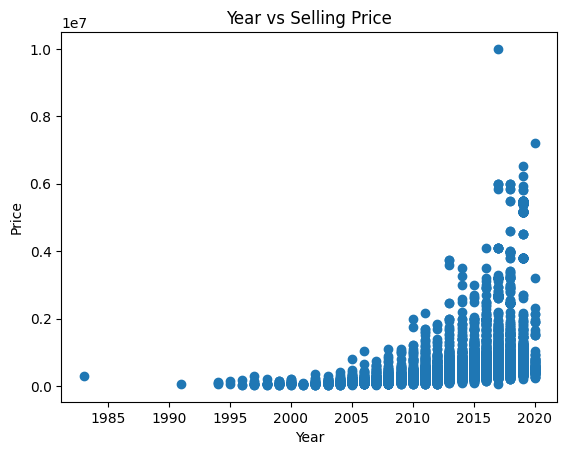

In [12]:
plt.figure()
plt.scatter(df['year'], df['selling_price'])
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

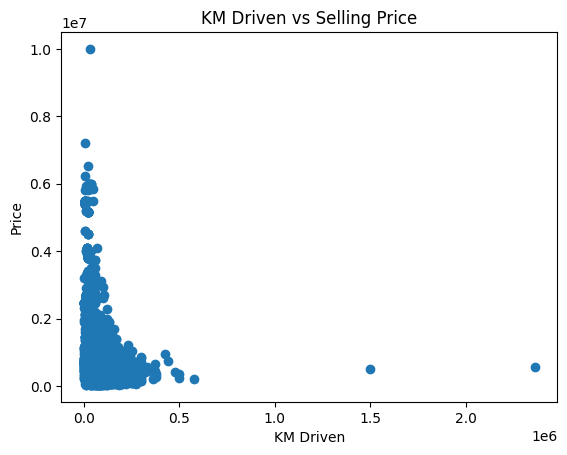

In [13]:
plt.figure()
plt.scatter(df['km_driven'], df['selling_price'])
plt.title("KM Driven vs Selling Price")
plt.xlabel("KM Driven")
plt.ylabel("Price")
plt.show()

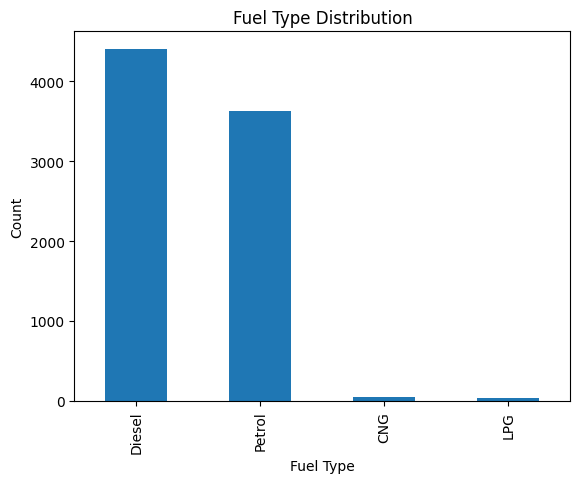

In [14]:
plt.figure()
df['fuel'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

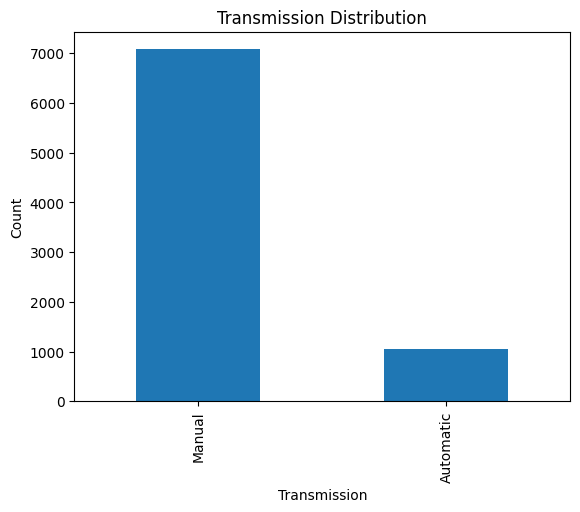

In [15]:
plt.figure()
df['transmission'].value_counts().plot(kind='bar')
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.show()

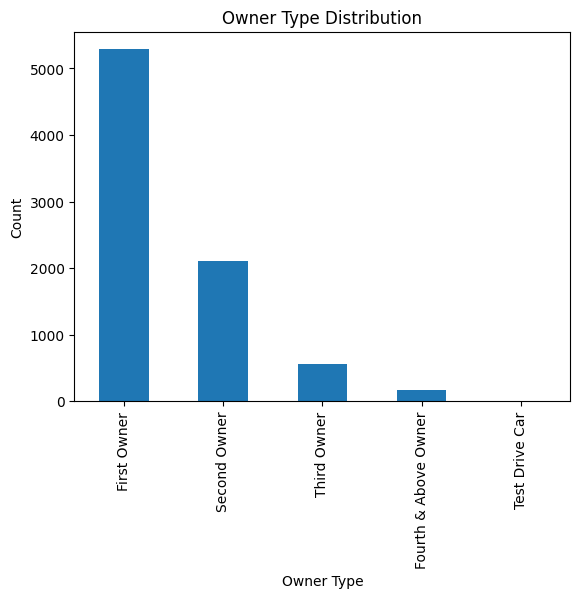

In [16]:
plt.figure()
df['owner'].value_counts().plot(kind='bar')
plt.title("Owner Type Distribution")
plt.xlabel("Owner Type")
plt.ylabel("Count")
plt.show()

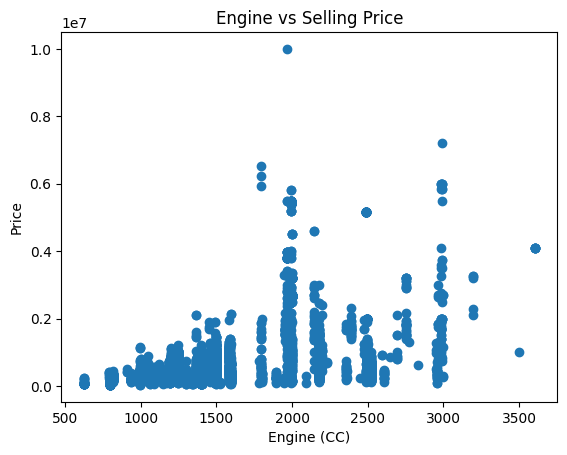

In [17]:
plt.figure()
plt.scatter(df['engine'], df['selling_price'])
plt.title("Engine vs Selling Price")
plt.xlabel("Engine (CC)")
plt.ylabel("Price")
plt.show()

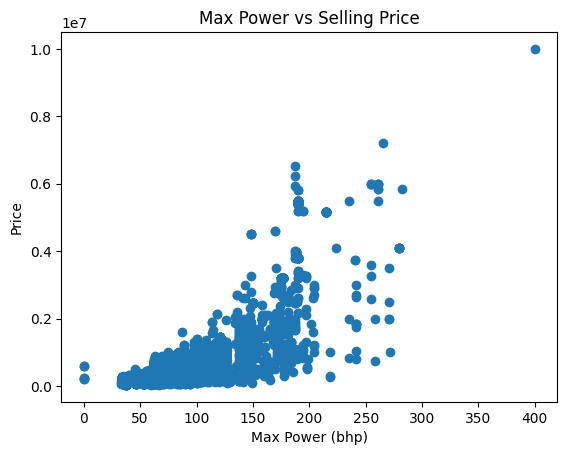


========== EDA COMPLETED SUCCESSFULLY ==========


In [18]:
plt.figure()
plt.scatter(df['max_power'], df['selling_price'])
plt.title("Max Power vs Selling Price")
plt.xlabel("Max Power (bhp)")
plt.ylabel("Price")
plt.show()

print("\n========== EDA COMPLETED SUCCESSFULLY ==========")

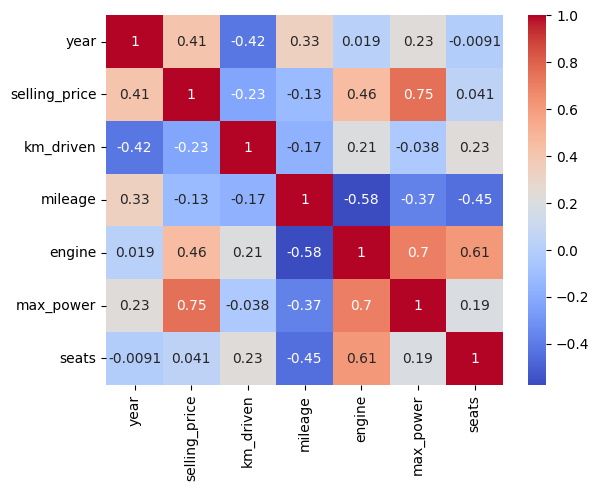

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


# FINAL EDA SUMMARY

- Dataset contains 8,128 used car records with 13 features
- Selling price is right-skewed with significant outliers
- Newer cars and lower km-driven cars command higher prices
- Automatic transmission and diesel fuel cars are more expensive
- First-owner vehicles have higher resale value
- Brand, engine capacity, and power strongly affect selling price
- Mileage, engine, max_power require data cleaning before modeling
